# Task 3

Due to the simplicity of KNN for Classification, let's focus on using a Pipeline and a GridSearchCV tool, since these skills can be generalized for any model.


## The Sonar Data

### Detecting a Rock or a Mine

Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels.



The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine).



Our main goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.


Data Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

### Complete the Tasks in bold

**TASK: Run the cells below to load the data.**

In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('sonar.all-data.csv')

In [7]:
df.head()

,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## Train | Test Split

Our approach here will be one of using Cross Validation on 90% of the dataset, and then judging our results on a final test set of 10% to evaluate our model.

**TASK: Split the data into features and labels, and then split into a training set and test set, with 90% for Cross-Validation training, and 10% for a final test set.**

*Note: The solution uses a random_state=42*

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
#M or R
X = df.drop('Label',axis=1)
y = df['Label']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

**TASK: Create a Pipeline that contains both a StandardScaler and a KNN model**

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

#scaler = StandardScaler()
#scaled_X_train = scaler.fit_transform(X_train)
#scaled_X_test = scaler.fit_transform(X_test)
#from sklearn.neighbors import KNeighborsClassifier
#knn_model = KNeighborsClassifier(n_neighbors=1)
#knn_model.fit(scaled_X_train,y_train)

In [13]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

**TASK: Perform a grid-search with the pipeline to test various values of k and report back the best performing parameters.**

In [14]:
from sklearn.model_selection import GridSearchCV

k_values = list(range(1, 31))
param_grid = {'knn__n_neighbors': k_values}


In [ ]:
grid_model = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)
#cv=5 means 5-fold cross-validation (divide the data into 5 parts)
#GridSearchCV tries all values of k
#it returns the best parameter setting based on average validation accuracy

In [16]:
grid_model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30]},
             scoring='accuracy')

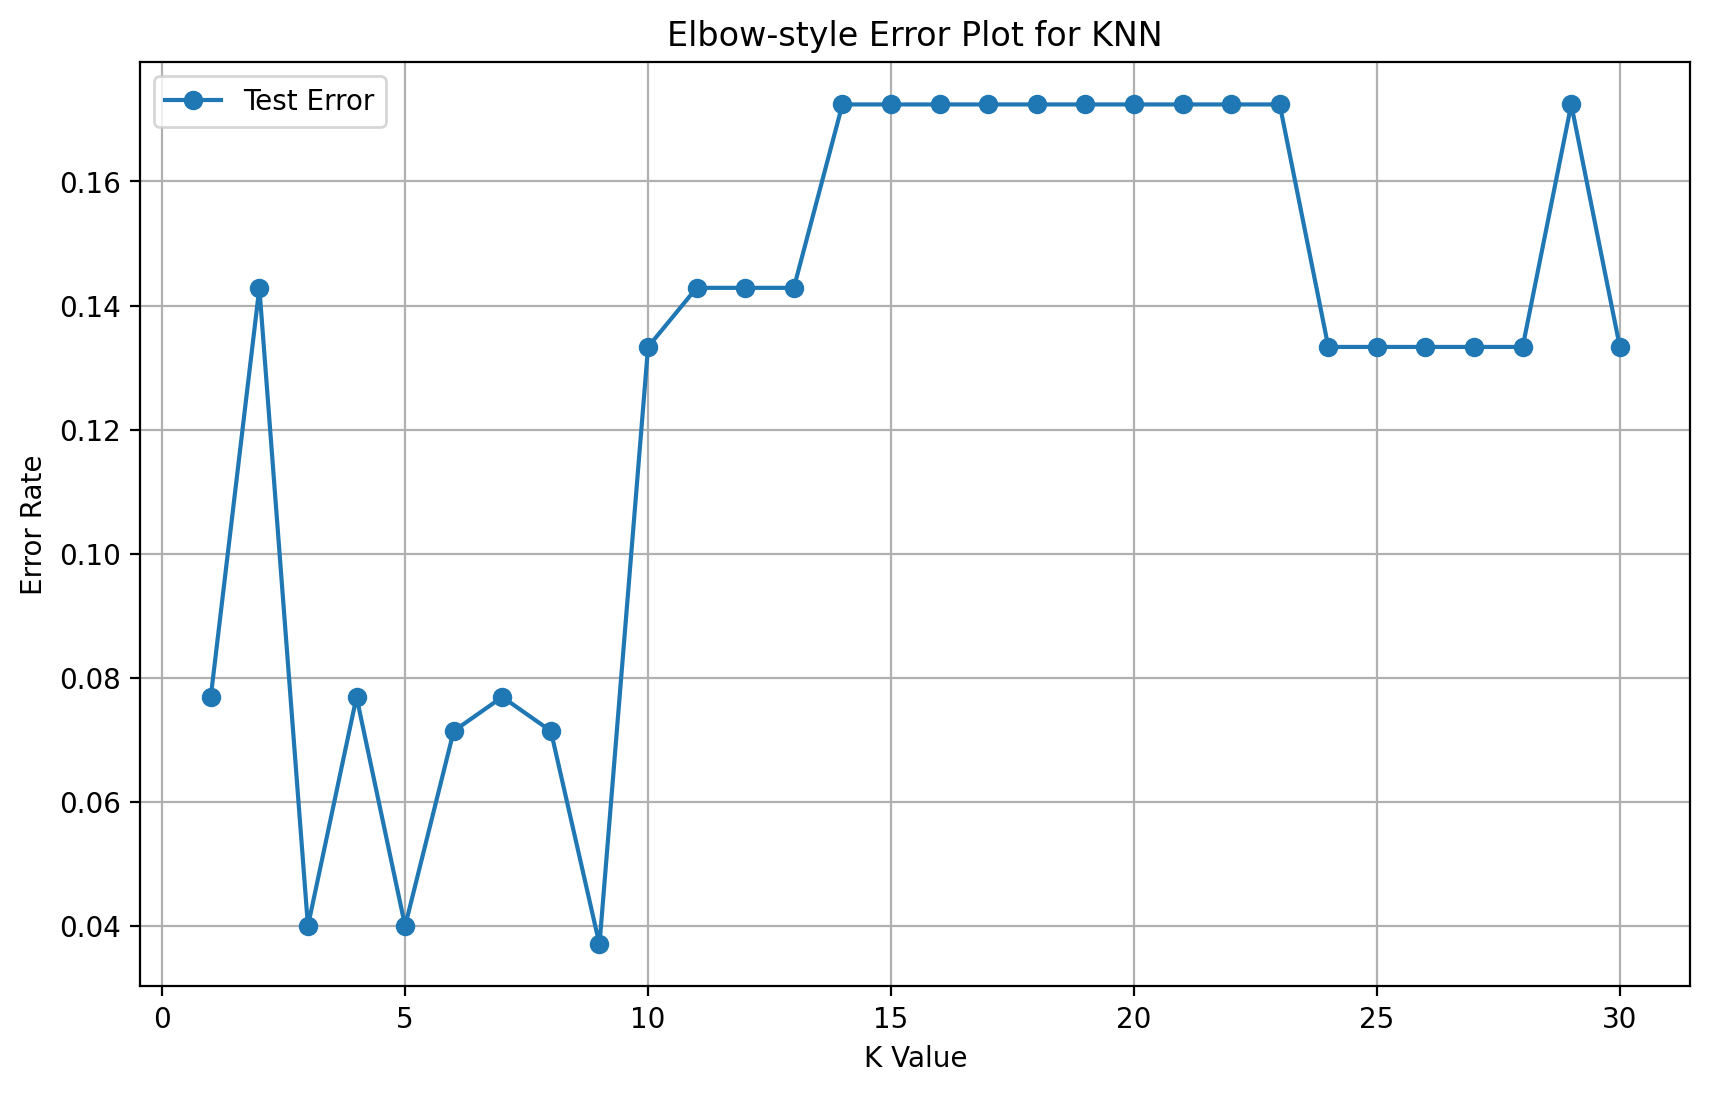

In [24]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

test_error_rates = []

for k in range(1, 31):
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    pipe_k.fit(X_train, y_train)
    y_pred_test = pipe_k.predict(X_test)
    
    test_error = 1 - f1_score(y_test, y_pred_test, pos_label='M')
    test_error_rates.append(test_error)

plt.figure(figsize=(10,6), dpi=200)
plt.plot(range(1, 31), test_error_rates, marker='o', label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')
plt.title('Elbow-style Error Plot for KNN')
plt.grid(True)
plt.show()

Trial for K=9


In [25]:
pipe_k9 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=9))
])

pipe_k9.fit(X_train, y_train)

y_pred_k9 = pipe_k9.predict(X_test)

print(classification_report(y_test, y_pred_k9))
print(confusion_matrix(y_test, y_pred_k9))

              precision    recall  f1-score   support

           M       0.93      1.00      0.96        13
           R       1.00      0.88      0.93         8

    accuracy                           0.95        21
   macro avg       0.96      0.94      0.95        21
weighted avg       0.96      0.95      0.95        21

[[13  0]
 [ 1  7]]


In [17]:
grid_model.best_params_

{'knn__n_neighbors': 1}

In [18]:
grid_model.best_score_

0.8453769559032717

### Final Model Evaluation

**TASK: Using the grid classifier object from the previous step, get a final performance classification report and confusion matrix.**

In [19]:
y_pred = grid_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           M       0.92      0.92      0.92        13
           R       0.88      0.88      0.88         8

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21

[[12  1]
 [ 1  7]]


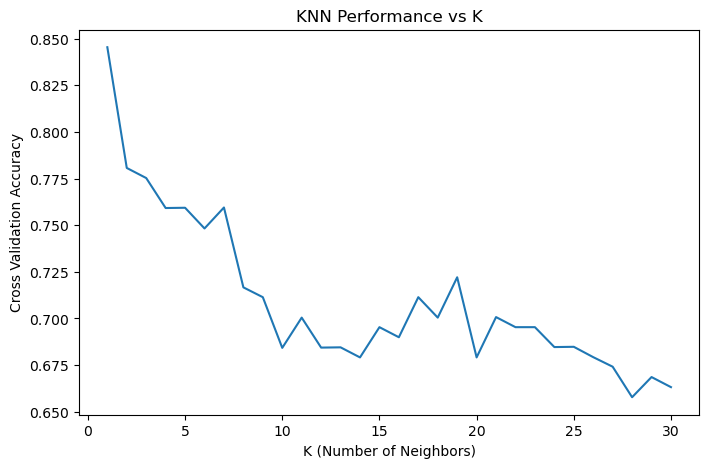

In [22]:
import matplotlib.pyplot as plt

scores = grid_model.cv_results_['mean_test_score']

plt.figure(figsize=(8,5))
plt.plot(k_values, scores)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross Validation Accuracy")
plt.title("KNN Performance vs K")
plt.show()

### Model Comparison

Two KNN models were compared: one using the optimal \(K\) found by **GridSearchCV** and another using \(K = 9\) suggested by the elbow-style error plot.

The \(K = 9\) model achieved a higher **test accuracy of 95%**, compared to **90%** for \(K = 1\), reducing the number of misclassifications from **two to one**.

This suggests that using a slightly larger neighborhood improves the **classification stability** for this dataset.